In [5]:
import numpy as np
import scipy as sp
from scipy.fft import fft, fftfreq, ifft
import matplotlib.pyplot as plt
from tqdm import trange

In [24]:
class BrunelNeuron():
    def __init__(self, w, refractory_period=2e-4):
        self.w = w # connection weights
        self.refractory_period = refractory_period # duration of the refractory period after spiking
        self.Vr = 10 # resting potential value
        self.Vth = 20 # spiking threshold
        self.tau = 20e-3 # Time constant of excitatory neurons, from Brunel
        self.reset()

    def reset(self):
        self.V = np.array([self.Vr])
        self.n_spikes = 0
        self.spikes = np.array([0])
        self.bRefractory = False # is not in refractory period

    def update_potential(self, x):
        if(self.bRefractory):
            self.V = np.concatenate([self.V, [self.Vth]])
            self.spikes = np.concatenante([self.spikes, 0])
            ref_duration = self.dt * (self.V.shape[0] - self.refractory_starting_time)
            if(ref_duration > self.refractory_period):
                self.V[-1] = self.Vr
                self.bRefractory = False
            return
        new_V = self.V[-1] + self.dt * (- self.V[-1] / self.tau + self.w @ x)
        self.V = np.concatenate([self.V, [new_V]])
        if(new_V > self.Vth):
            self.V[-1] = self.Vth
            self.spikes = np.concatenate([self.spikes, 1])
            self.n_spikes += 1
            self.bRefractory = True
            self.refractory_starting_time = self.V.shape[0]


In [45]:
class BrunelModelA():
    def __init__(self, N, Next, g, J, Ce, D:int, vext):
        self.N = N
        self.N1 = int(0.8*N) # excitatory neurons
        self.N2 = int(0.2*N) # inhibitory neurons
        self.Je = J
        self.g = g
        self.Ji = g * J
        self.Ce = Ce
        self.Ci = 0.25 * Ce
        self.D = D
        self.Next = Next
        self.vext = vext
        
        self.neurons = []
        for i in range(self.N):
            w = np.concatenate([np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.N1),
                                np.random.choice([0, self.Ji], p=[1-self.Ci/self.N2, self.Ci/self.N2], size = self.N2),
                                np.random.choice([0, self.Je], p=[1-self.Ce/self.N1, self.Ce/self.N1], size = self.Next)])
            self.neurons.append(BrunelNeuron(w))

    def retrieve_potential(self, idx):
        V = []
        for neuron in self.neurons:
            V.append(neuron.V[idx])
        return np.array(V)

    def retrieve_spikes(self, idx):
        spikes = []
        for neuron in self.neurons:
            if(np.abs(idx)>neuron.spikes.shape[0]):
                spikes.append(0)
            else:
                spikes.append(neuron.spikes[idx])
        return np.array(spikes)
    
    def compute_step(self):
        network_spikes = self.retrieve_spikes(-1-self.D)
        external_spikes = np.random.choice([0, 1], p=[1 - self.dt * self.vext, self.dt * self.vext], size = self.Next)
        spikes = np.concatenate([network_spikes, external_spikes])
        for neuron in self.neurons:
            neuron.update_potential(spikes)

    def compute_activity(self, T, dt):
        n_steps = int(T//dt)
        self.t = T
        self.dt = dt
        self.n_steps = n_steps
        for neuron in self.neurons:
            neuron.reset()
            neuron.dt = dt
        for i in trange(n_steps - 1):
            self.compute_step()

    def plot_raster(self):
        event = []
        for neuron in self.neurons:
            st = neuron.spikes
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)

In [62]:
model = BrunelModelA(N = 10000, Next = 800, g=1, J=0.2, Ce=4000, D=0, vext=200)

In [ ]:
model.compute_activity(1, 0.001)

  0%|                                                                                          | 0/998 [00:00<?, ?it/s]

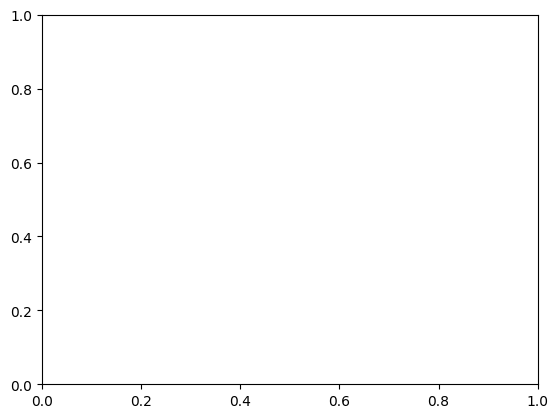

In [58]:
model.plot_raster()

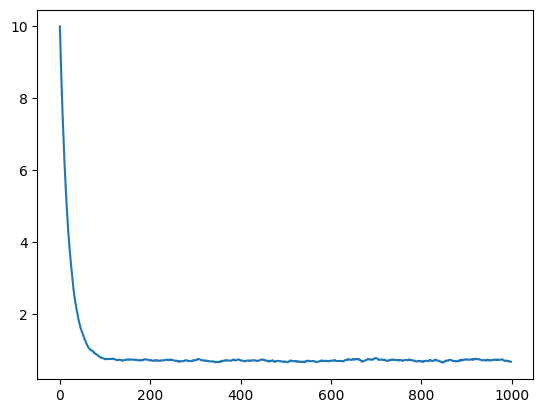

In [61]:
neuron = model.neurons[0]
plt.plot(neuron.V)